In [1]:
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, rdFingerprintGenerator
from rdkit.Chem import Draw
import pandas as pd
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np


In [2]:
cat =["[NH4+]",
"CC[NH3+]",
"CCCC[NH3+]",
"CCCCCC[NH3+]",
"C[N+](C)(C)(C)",
"CC[N+](CC)(CC)(CC)",
"CCC[N+](CCC)(CCC)(CCC)",
"CC[N+](C)(C)(C)",
"CCCC[N+](C)(C)(C)",
"CCCCCC[N+](C)(C)(C)",
"C(C)(C)(C)C[N+](C)(C)(C)",
"C1=CC=CC=C1C[N+](C)(C)(C)",
"C1CC[N+](C)(C)C1",
"C1CC[N+](C)(CC)C1",
"C1CC[N+](C)(CCCC)C1",
"C1CC[N+](C)(CCCCCC)C1",
"C1CCC[N+](C)(C)C1",
"C1CCC[N+](CC)(C)C1",
"C1CCC[N+](CCCC)(C)C1",
"C1CCC[N+](CCCC)(C)C1",
"C1CC[N+](C2)(CCC2)C1",
"C1CCC[N+](C2)(CCCC2)C1",
"C1CCC[N+](C2)(CCC(CCC)C2)C1",
"C1=C[N+](C)(C)C=C1",
"C1=C[N+](C)(CC)C=C1",
"C1=C[N+](C)(CCCC)C=C1",
"C1=C[N+](C)(CCCCCC)C=C1",
"C1=CC=C[N+](C)=C1",
"C1=CC=C[N+](CC)=C1",
"C1=CC=C[N+](CCCC)=C1",
"C1=CC=C[N+](CCCCCC)=C1",
"CN1C=C[N+](CC)=C1(C)",
"CN1C=C[N+](CCCC)=C1(C)",
"CN1C=C[N+](CCCCCC)=C1(C)",
"CN1C(C)=C(C)[N+](C)=C1(C)",
"CN1C(C)=C(C)[N+](C)=C1(C1=CC=CC=C1)",
"CN1C2=CC=CC=C2[N+](=C1(C))C",
"CN1C2=CC=CC=C2[N+](=C1C3=CC=CC=C3)C",
"CN1C(C2=CC=CC=C2)=C(C3=CC=CC=C3)[N+](C)=C1(C)",
"CN1C(C2=CC=CC=C2)=C(C3=CC=CC=C3)[N+](C)=C1(C4=CC=CC=C4)",
"[S+](CC)(CC)(CC)",
"[S+](C1=CC=CC=C1)(C2=CC=CC=C2)(C3=CC=CC=C3)",
"[P+](C)(C1=CC=CC=C1)(C2=CC=CC=C2)(C3=CC=CC=C3)",
"[P](N(C)(C))(N(C)(C))(N(C)(C))([NH+](C)(C))"]

      

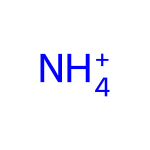

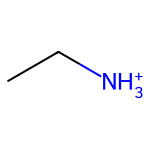

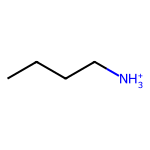

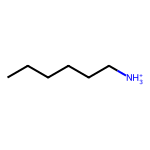

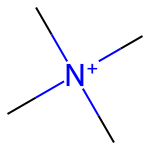

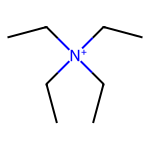

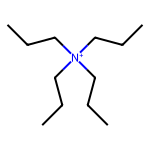

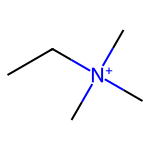

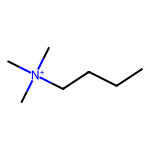

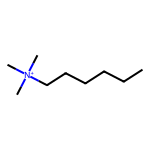

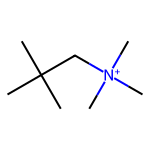

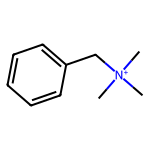

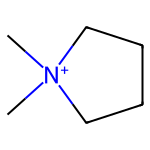

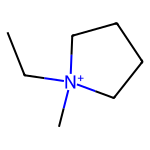

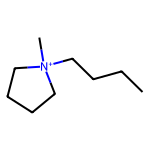

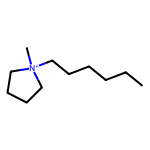

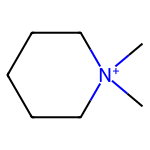

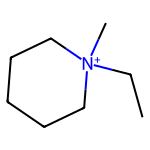

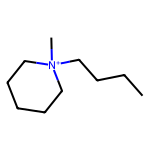

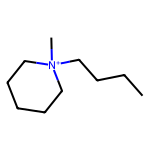

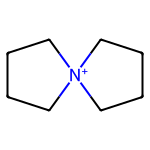

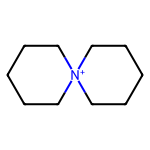

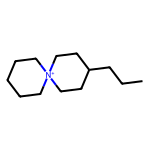

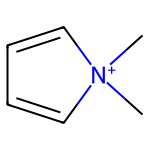

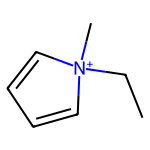

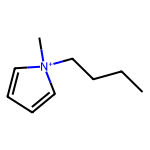

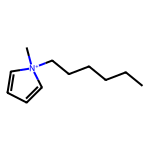

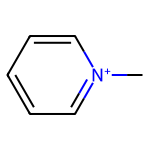

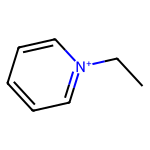

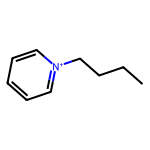

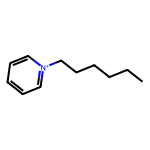

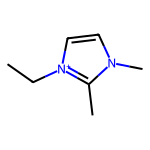

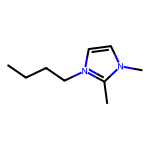

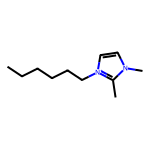

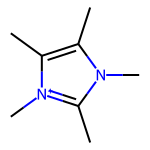

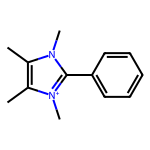

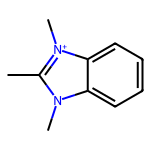

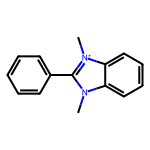

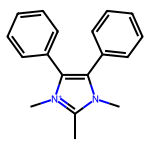

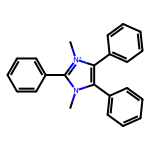

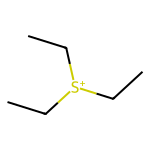

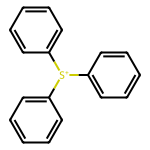

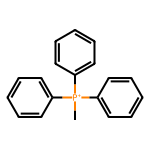

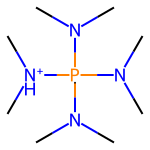

In [3]:
df = pd.DataFrame()
df["SMILES"]=cat
image_paths= []

for indx, i in enumerate(cat):
    mol = Chem.MolFromSmiles(i)
    mol_image = Draw.MolToImage(mol, size=(150, 150))  # Generate image
    mw= Descriptors.ExactMolWt(mol) #molecular weight
    logp= Crippen.MolLogP(mol) #LogP (Partition Coefficient)
    #vdw= rdMolDescriptors.CalcNumValenceElectrons(mol)
    tpsa= rdMolDescriptors.CalcTPSA(mol) #Topological Polar Surface Area (TPSA)"
    hdon= Lipinski.NumHDonors(mol) #H-Bond Donors
    hacc= Lipinski.NumHAcceptors(mol) #H-Bond Acceptors
    rot= rdMolDescriptors.CalcNumRotatableBonds(mol) #Rotatable Bonds
    nrings= rdMolDescriptors.CalcNumRings(mol) #Number of Rings
    nar= rdMolDescriptors.CalcNumAromaticRings(mol) #Number of Aromatic Rings
    fsp3= rdMolDescriptors.CalcFractionCSP3(mol) #Fraction of sp3 Carbons
    
    df.loc[indx,"MolWt"]=mw
    df.loc[indx,"PC"]=logp
    df.loc[indx,"TPSA"]=tpsa
    df.loc[indx,"NumHDonors"]=hdon
    df.loc[indx,"NumHAcceptors"]=hacc
    df.loc[indx,"PC"]=rot
    df.loc[indx,"RingCount"]=nrings
    df.loc[indx,"AromaticCount"]=nar
    df.loc[indx,"Fraction"]=fsp3
    img_path= f"mol_str\mol_{indx}.png"
    display(mol_image)
    mol_image.save(img_path) 
    image_paths.append(img_path)
   


In [4]:
df

,SMILES,MolWt,PC,TPSA,NumHDonors,NumHAcceptors,RingCount,AromaticCount,Fraction
0,[NH4+],18.033826,0.0,36.50,1.0,0.0,0.0,0.0,0.000000
1,CC[NH3+],46.065126,0.0,27.64,1.0,0.0,0.0,0.0,1.000000
2,CCCC[NH3+],74.096426,2.0,27.64,1.0,0.0,0.0,0.0,1.000000
3,CCCCCC[NH3+],102.127726,4.0,27.64,1.0,0.0,0.0,0.0,1.000000
4,C[N+](C)(C)(C),74.096426,0.0,0.00,0.0,0.0,0.0,0.0,1.000000
5,CC[N+](CC)(CC)(CC),130.159026,4.0,0.00,0.0,0.0,0.0,0.0,1.000000
6,CCC[N+](CCC)(CCC)(CCC),186.221626,8.0,0.00,0.0,0.0,0.0,0.0,1.000000
7,CC[N+](C)(C)(C),88.112076,1.0,0.00,0.0,0.0,0.0,0.0,1.000000
8,CCCC[N+](C)(C)(C),116.143376,3.0,0.00,0.0,0.0,0.0,0.0,1.000000
9,CCCCCC[N+](C)(C)(C),144.174676,5.0,0.00,0.0,0.0,0.0,0.0,1.000000


In [17]:
df_new = pd.DataFrame()
for indx, i in enumerate(cat):
    mol = Chem.MolFromSmiles(i)
    df_new[indx]=Descriptors.CalcMolDescriptors(mol)


In [21]:
df_new.head(10)

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
MaxAbsEStateIndex,0.000000,3.486111,3.675417,3.757491,2.125000,2.274306,2.313472,2.180556,2.231806,2.255899,...,2.203704,2.240741,2.203704,2.240741,2.261574,2.298611,2.273920,2.211420,2.409722,2.335648
MaxEStateIndex,0.000000,3.486111,3.675417,3.757491,2.125000,2.274306,2.313472,2.180556,2.231806,2.255899,...,2.203704,2.240741,2.203704,2.240741,2.261574,2.298611,2.273920,2.211420,2.409722,2.335648
MinAbsEStateIndex,0.000000,1.000000,1.093750,1.111111,1.000000,1.277778,1.333333,1.069444,1.105000,1.114796,...,1.300926,1.255185,1.274259,1.228519,1.238617,1.192876,0.754630,0.014630,1.428148,1.367284
MinEStateIndex,0.000000,1.000000,1.093750,1.111111,1.000000,1.277778,1.333333,1.069444,1.105000,1.114796,...,1.300926,1.255185,1.274259,1.228519,1.238617,1.192876,0.754630,-0.014630,-1.526435,-1.367284
qed,0.393213,0.371491,0.478298,0.508648,0.362984,0.509702,0.509390,0.414091,0.490049,0.410006,...,0.469520,0.625000,0.515090,0.560802,0.625811,0.476136,0.495659,0.596397,0.641560,0.626235
SPS,0.000000,6.000000,8.400000,9.428571,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,10.500000,10.666667,10.916667,10.941176,10.750000,10.800000,10.285714,10.578947,11.250000,13.846154
MolWt,18.039000,46.093000,74.147000,102.201000,74.147000,130.255000,186.363000,88.174000,116.228000,144.282000,...,139.222000,201.293000,161.228000,223.299000,263.364000,325.435000,119.253000,263.385000,277.327000,208.290000
HeavyAtomMolWt,14.007000,38.029000,62.051000,86.073000,62.051000,110.095000,158.139000,74.062000,98.084000,122.106000,...,124.102000,184.157000,148.124000,208.179000,244.212000,304.267000,104.133000,248.265000,259.183000,183.090000
ExactMolWt,18.033826,46.065126,74.096426,102.127726,74.096426,130.159026,186.221626,88.112076,116.143376,144.174676,...,139.122975,201.138625,161.107325,223.122975,263.154275,325.169925,119.088898,263.088898,277.114064,208.181135
NumValenceElectrons,8.000000,20.000000,32.000000,44.000000,32.000000,56.000000,80.000000,38.000000,50.000000,62.000000,...,56.000000,78.000000,62.000000,84.000000,100.000000,122.000000,44.000000,92.000000,98.000000,81.000000


In [22]:
df_new.to_csv("molecular_descriptors.csv")